<a href="https://colab.research.google.com/github/kailiwheeler/dsa425/blob/main/PCA_Food_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import svd
import seaborn as sns

## Part 1

In [3]:
df = pd.read_csv('Food_consumption.csv',index_col='Country')
df_high = (df[df['Income_level']=='High'])
print(df[df['Income_level']=='High'].index)
df_low = df[df['Income_level']=='Low']
print(df[df['Income_level']=='Low'].index)


Index(['Chile', 'Mexico'], dtype='object', name='Country')
Index(['Afghanistan', 'Armenia', 'Burkina Faso', 'Ethiopia ', 'Malawi', 'Mali',
       'Niger', 'Nigeria', 'Pakistan', 'Senegal', 'Somalia', 'Togo'],
      dtype='object', name='Country')


## Part 2: Data Exploration

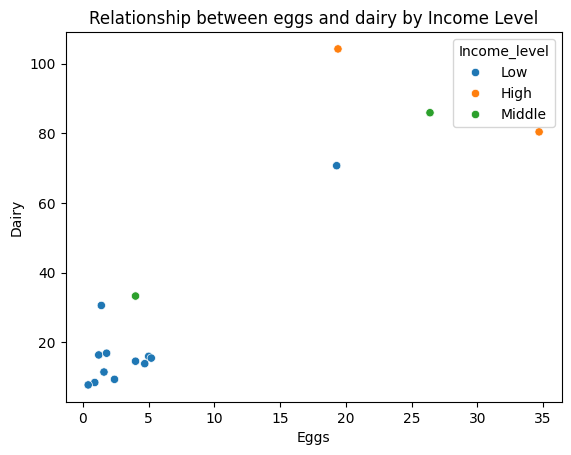

In [4]:
sns.scatterplot(data=df, x='eggs', y='meat', hue='Income_level')
plt.xlabel('Eggs')
plt.ylabel('Dairy')
plt.title('Relationship between eggs and dairy by Income Level')
plt.show()

The plot above shows a positive correlation between the consumption of eggs and dairy in each country. Meaning that as the consumption of eggs increase in a country, the consumption of dairy also increases. It is also important to note the furthest point on both axises are countries of high income level. Meaning that the lower the income level, the lower the consumption of dairy and eggs a country has.

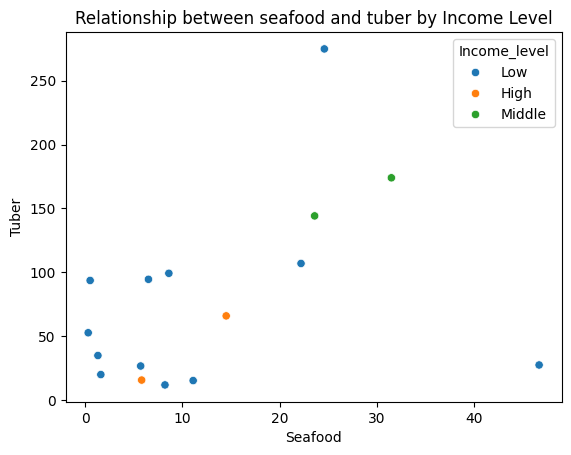

In [5]:
sns.scatterplot(data=df, x='seafood',y='tuber',hue='Income_level')
plt.xlabel('Seafood')
plt.ylabel('Tuber')
plt.title('Relationship between seafood and tuber by Income Level')
plt.show()

The plot above shows a positive correlation between the consumption of seafood and tuber in each country. Meaning that as the consumption of seafood increase in a country, the consumption of tuber also increases. It is also important to note the countries with the higher income level have a very low consumption of both seafood and tuber, whereas the countries with low and medium income level range in their consumption.

---



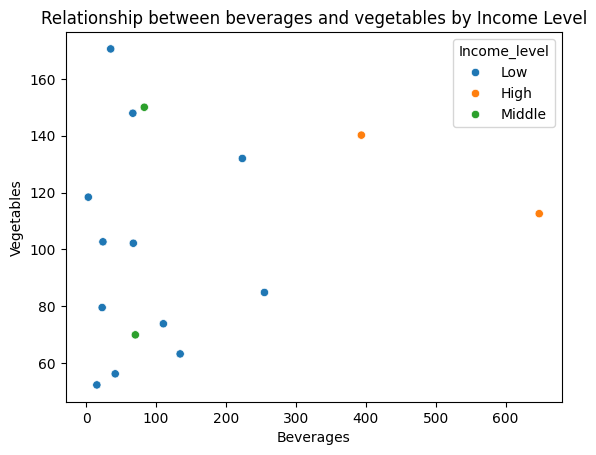

In [6]:
sns.scatterplot(data=df, x='beverages', y='vegetables', hue='Income_level')
plt.xlabel('Beverages')
plt.ylabel('Vegetables')
plt.title('Relationship between beverages and vegetables by Income Level')
plt.show()

The plot above shows the lack of correlation between the consumption of beverages and vegetables since the data points have no trend. However, it does show the correlation between beverage consumption and income level, being that the higher income level have a higher beverage consumption compared to the low and medium income levels.

## Part 2: PCA

In [7]:
df_reduced = df.drop('Income_level', axis = 1)
df_scaled = (df_reduced - df_reduced.mean()) / df_reduced.std() #this is from the template
df_pca = PCA().fit(df_scaled)
df_scaled = df_scaled.dropna() #add this line right afterdf_pca = PCA().fit(df_scaled)
cores = df_pca.transform(df_scaled)
print(f"Proportion of variance explained by each principal component:\n{df_pca.explained_variance_ratio_}")


Proportion of variance explained by each principal component:
[0.35440169 0.21634952 0.13323964 0.0959137  0.05877018 0.05639165
 0.03756551 0.02008389 0.01508698 0.00655342 0.00319224 0.00245159]


## Part 2: Interpretation

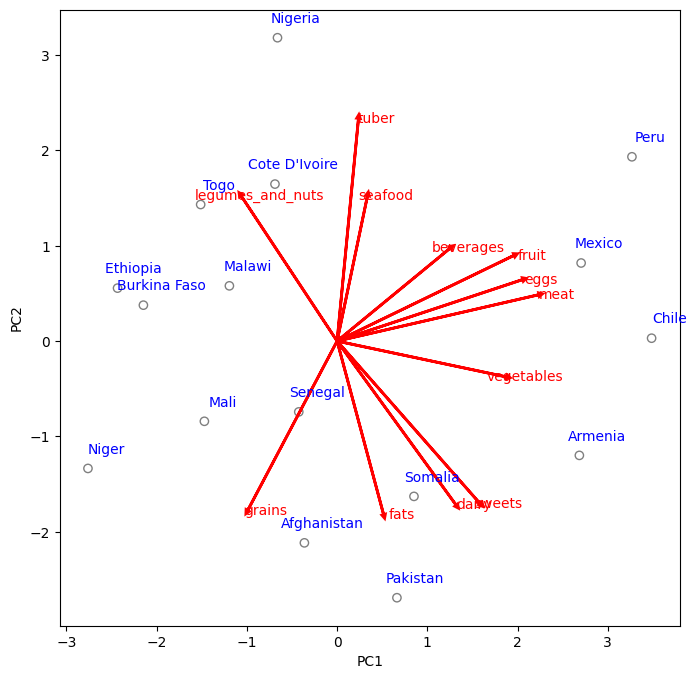

In [8]:
scores = df_pca.transform(df_scaled)
scale_factor = 5
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    scores[:, 0],
    scores[:, 1],
    color="none",
    edgecolor="k",
    alpha=0.5,
)
for i in range(df_pca.components_.shape[1]):
    ax.arrow(
        0,
        0,
        scale_factor*df_pca.components_[0, i],
        scale_factor*df_pca.components_[1, i],
        head_width=0.04,
        head_length=0.04,
        linewidth=2,
        color="red",
    )
    ax.text(
        scale_factor*df_pca.components_[0, i] + .2,
        scale_factor*df_pca.components_[1, i],
        df_reduced.columns[i],
        color="red",
        ha="center",
        va="center",
    )
for i in range(scores.shape[0]):
    ax.text(
        scores[i, 0] + 0.2,
        scores[i, 1] + 0.2,
        df_scaled.index[i],
        color="blue",
        ha="center",
        va="center",
    )
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

a) 35.44% of the variance is descibed by the first dimention and 57.07% by the first two dimentions combined.

b) PC1 contain food categories like grains, leegumes, and nuts on the left and eggs, meat, and dairy on the right. This represents the varaition in animal products versus plant products consumed by the country. PC2 contain food categories like fats, dairy, and sweets on the left and tuber,seafood, legumes, and nuts on the right. This represents the variation in fresh produce versus processed food.


c) The most important factor of variance in the food cunsumption of countries is the difference in whether they consume more plant or animal based products (PC1). Following that, the next largest indicator of varance in food consumption is the difference in the consumption of fresh versus processed food (PC2). These two indicators combined account for 57%% of the variance in food consumption between countries. Factors like geographic location (ex. Cote D'Ivoire, Togo, and Burkina Faso) and income level may cause countries to have similar consumptions.